In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import string

# --- Matplotlib 中文與字體設置 (請根據您的系統配置) ---
mpl.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
mpl.rcParams['axes.unicode_minus'] = False 

# --- 數據轉換工具 ---
def unipolarize(bipolar_pattern):
    """將 (+1, -1) 轉換回 (0, 1)"""
    return (bipolar_pattern + 1) // 2

def bipolarize(patterns):
    """將 (0, 1) 轉換為 (+1, -1)"""
    return 2 * patterns - 1

import numpy as np
import os
import string 

def load_data(file_path, rows, cols):
    """
    【10x11 魯棒模式】解析 ASCII 藝術檔案。
    - 讀取 ROWS+1 行數據 (例如 11 行)，將模式間的單個空行視為額外行。
    - 數據處理後，返回 ROWS x COLS (10x10) 的有效數據。
    """
    # 實際讀取的行數
    READ_ROWS = rows + 1  # 例如：10 + 1 = 11
    
    # 每個模式的總數據點數 (11 * 10 = 110)
    TOTAL_READ_SIZE = READ_ROWS * cols 
    
    patterns_list = []
    current_pattern_data = []
    
    # ... (錯誤檢查和檔案讀取保持不變) ...
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            
        for line_num, line in enumerate(lines, 1):
            
            line_cleaned = line.strip('\n') 
            line_stripped = line_cleaned.strip()
            is_empty_data_line = not line_stripped
            
            row_data = [0] * cols # 初始化一行 COLS 個 0
            
            if is_empty_data_line:
                 # 遇到空行 -> 這是 11 行中的一員，補 0
                 # row_data 已經是 [0] * cols，無需操作
                 pass 
            else:
                 # 遇到非空行 -> 逐字符解析前 COLS 個字符
                 
                 for i in range(cols):
                     try:
                         # 僅使用 line_cleaned 進行索引 (不進行任何偏移修正)
                         char = line_cleaned[i]
                         
                         if char == '1':
                             row_data[i] = 1
                         # 否則 (char 是空格/其他)，row_data[i] 保持為 0
                             
                     except IndexError:
                         # 行寬不足，後續已經是 0，直接跳出
                         break

            # 累積數據點
            current_pattern_data.extend(row_data)
            
            # 立即檢查模式是否完成 (總點數達到 110)
            if len(current_pattern_data) == TOTAL_READ_SIZE:
                
                # 📌 關鍵步驟：忽略最後一行數據 (即分隔符)
                valid_pattern_data = np.array(current_pattern_data)[:-cols] # 忽略最後 cols (10) 個點
                patterns_list.append(valid_pattern_data)
                
                print(f"模式 #{len(patterns_list)} 完成，使用到 L{line_num}。")
                
                current_pattern_data = [] # 清空，準備收集下一個圖案
            
            elif len(current_pattern_data) > TOTAL_READ_SIZE:
                # 修正：如果數據超出，表示分隔符錯誤或連續空行被視為數據。
                # 這裡需要將 current_pattern_data 截斷到 TOTAL_READ_SIZE 的倍數
                
                # 為了避免複雜的截斷邏輯，我們只在末端處理
                pass


        # 處理文件結束時，可能不足 TOTAL_READ_SIZE 的不完整模式
        if len(current_pattern_data) >= cols: # 至少有 ROW=1 行數據
            # 如果數據量介於 110 到 219 之間 (例如多了一個不完整的模式)
            
            # 為了簡化，我們只處理不足 TOTAL_READ_SIZE 的情況
            if len(current_pattern_data) % TOTAL_READ_SIZE != 0:
                print(f"警告：檔案末端有不完整的數據 ({len(current_pattern_data)} 點)，已忽略。")
        
    except Exception as e:
        print(f"解析 ASCII 藝術檔案時發生錯誤：{e}")
        return None
    
    if not patterns_list:
        print("警告：未成功解析出任何完整圖案。請檢查檔案格式。")
        return None
        
    print(f"成功解析出 {len(patterns_list)} 個完整圖案。")
    # 將所有圖案堆疊成 N x M 矩陣 (N=100, M=模式數)
    return np.stack(patterns_list).T

In [7]:
# --- Matplotlib 繪圖函數 ---
def print_patterns_visual(bipolar_patterns, rows, cols, title_suffix):
    """
    視覺化所有載入的模式。
    """
    M = bipolar_patterns.shape[1]
    plot_cols = min(M, 5) 
    plot_rows = int(np.ceil(M / plot_cols))
    
    fig, axes = plt.subplots(plot_rows, plot_cols, figsize=(plot_cols * 3.5, plot_rows * 4))
    
    if M == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for p in range(M):
        pattern_bipolar = bipolar_patterns[:, p]
        pattern_img = unipolarize(pattern_bipolar).reshape(rows, cols)

        ax = axes[p]
        ax.imshow(pattern_img, cmap='gray')
        ax.set_title(f"模式 #{p+1}")
        
        ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
        ax.grid(which='minor', color='red', linestyle='-', linewidth=0.5)
        ax.tick_params(which='minor', size=0)
        ax.axis('off')

    for i in range(M, len(axes)):
        axes[i].axis('off')

    plt.suptitle(f"數據驗證：{title_suffix} (M={M} 個)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


🚀 獨立數據驗證模式：開始檢查 Bonus (10x10) 數據
模式 #1 完成，使用到 L11。
模式 #2 完成，使用到 L22。
模式 #3 完成，使用到 L33。
模式 #4 完成，使用到 L44。
模式 #5 完成，使用到 L55。
模式 #6 完成，使用到 L66。
模式 #7 完成，使用到 L77。
模式 #8 完成，使用到 L88。
模式 #9 完成，使用到 L99。
模式 #10 完成，使用到 L110。
模式 #11 完成，使用到 L121。
模式 #12 完成，使用到 L132。
模式 #13 完成，使用到 L143。
模式 #14 完成，使用到 L154。
模式 #15 完成，使用到 L165。
成功解析出 15 個完整圖案。


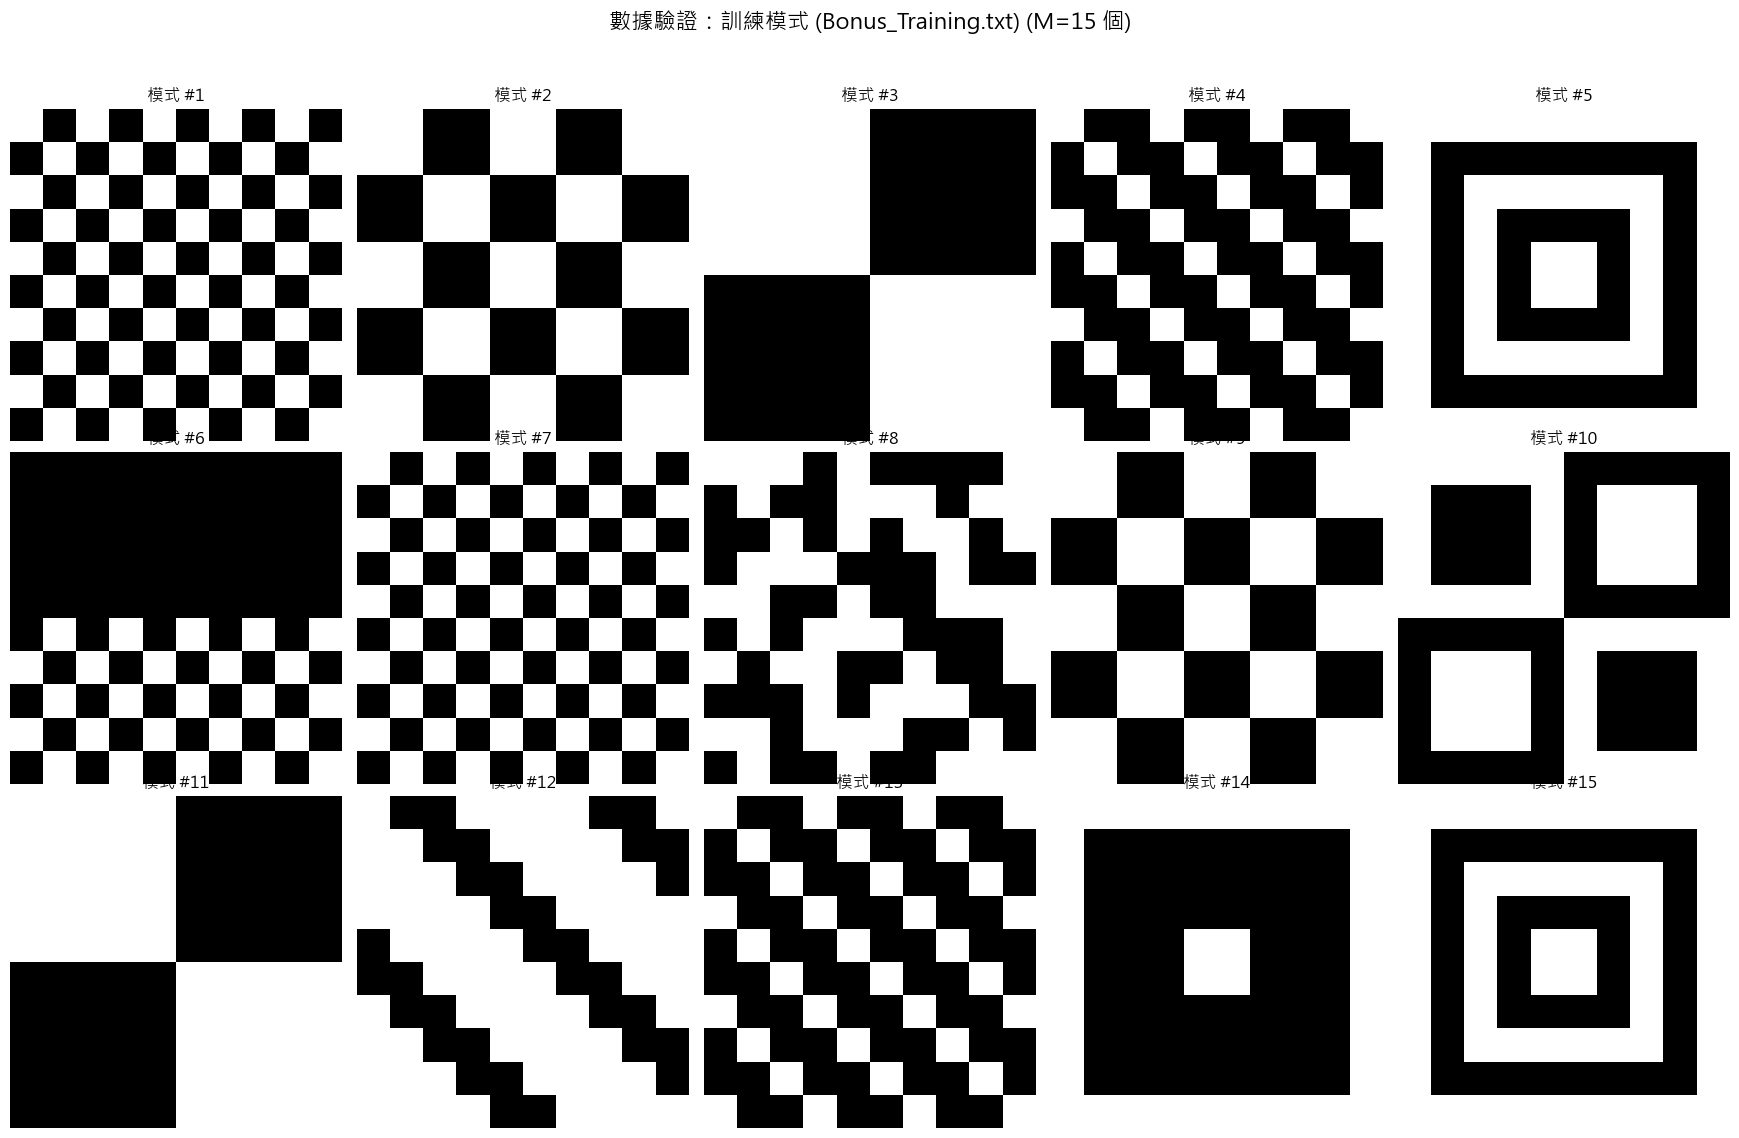


-------------------------------------------------------
模式 #1 完成，使用到 L11。
模式 #2 完成，使用到 L22。
模式 #3 完成，使用到 L33。
模式 #4 完成，使用到 L44。
模式 #5 完成，使用到 L55。
模式 #6 完成，使用到 L66。
模式 #7 完成，使用到 L77。
模式 #8 完成，使用到 L88。
模式 #9 完成，使用到 L99。
模式 #10 完成，使用到 L110。
模式 #11 完成，使用到 L121。
模式 #12 完成，使用到 L132。
模式 #13 完成，使用到 L143。
模式 #14 完成，使用到 L154。
警告：檔案末端有不完整的數據 (100 點)，已忽略。
成功解析出 14 個完整圖案。


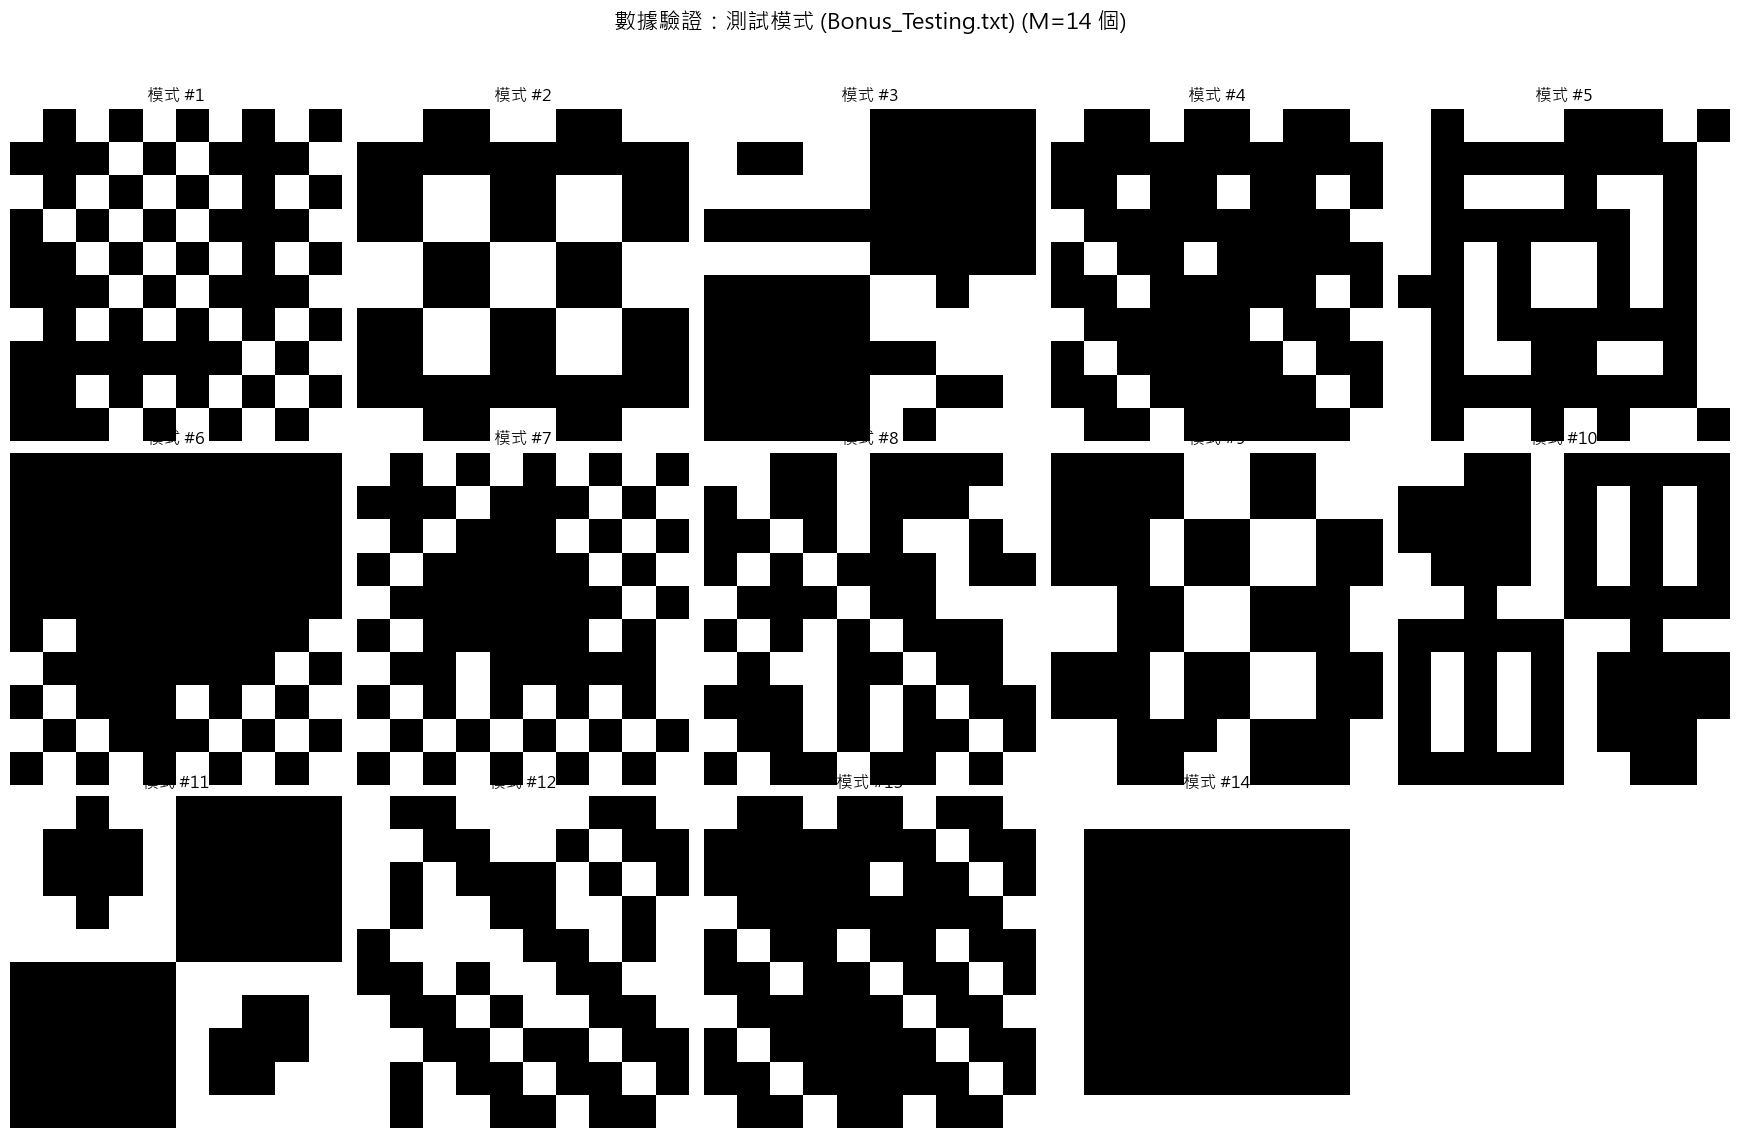

數據驗證完成。


In [10]:
# --- 主除錯程序 ---
def main_bonus_data_check():
    ROWS = 10
    COLS = 10
    
    # 設置檔案路徑
    BONUS_TRAINING_FILE = './Hopfield_dataset/Bonus_Training.txt'
    BONUS_TESTING_FILE = './Hopfield_dataset/Bonus_Testing.txt'
    
    print("\n=======================================================")
    print("🚀 獨立數據驗證模式：開始檢查 Bonus (10x10) 數據")
    print("=======================================================")

    # 1. 檢查訓練資料
    training_uni = load_data(BONUS_TRAINING_FILE, ROWS, COLS)
    if training_uni is not None:
        training_bipolar = bipolarize(training_uni)
        print_patterns_visual(training_bipolar, ROWS, COLS, "訓練模式 (Bonus_Training.txt)")

    print("\n-------------------------------------------------------")

    # 2. 檢查測試資料
    testing_uni = load_data(BONUS_TESTING_FILE, ROWS, COLS)
    if testing_uni is not None:
        testing_bipolar = bipolarize(testing_uni)
        print_patterns_visual(testing_bipolar, ROWS, COLS, "測試模式 (Bonus_Testing.txt)")
        
    print("=======================================================")
    print("數據驗證完成。")
    
if __name__ == "__main__":
    main_bonus_data_check()